# Week 3 - Visualization & Dashboard

Demonstrates the reusable plotting functions in `src/visualizations.py` (the same functions that power `dashboard/app.py`), on the Week 1 cleaned heart disease data.

Run the interactive Streamlit dashboard itself with:

```bash
streamlit run dashboard/app.py
```

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import DataLoader
from src.statistics import StatisticalAnalyzer
from src.visualizations import (
    plot_histogram_with_distribution,
    create_correlation_heatmap,
    plot_boxplots_by_category,
    create_interactive_scatter,
    plot_qq_comparison,
    dashboard_layout,
)

# Load the Week 1 cleaned data
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

# Re-apply categorical dtype (dtype doesn't survive a plain CSV round-trip)
for col in df.columns:
    if df[col].nunique() < 10:
        df[col] = df[col].astype('category')

analyzer = StatisticalAnalyzer(df)

print("=" * 60)
print("VISUALIZATION MODULE DEMO")
print("=" * 60)
print(f"Loaded {df.shape[0]} patients, {df.shape[1]} columns")

VISUALIZATION MODULE DEMO
Loaded 302 patients, 16 columns

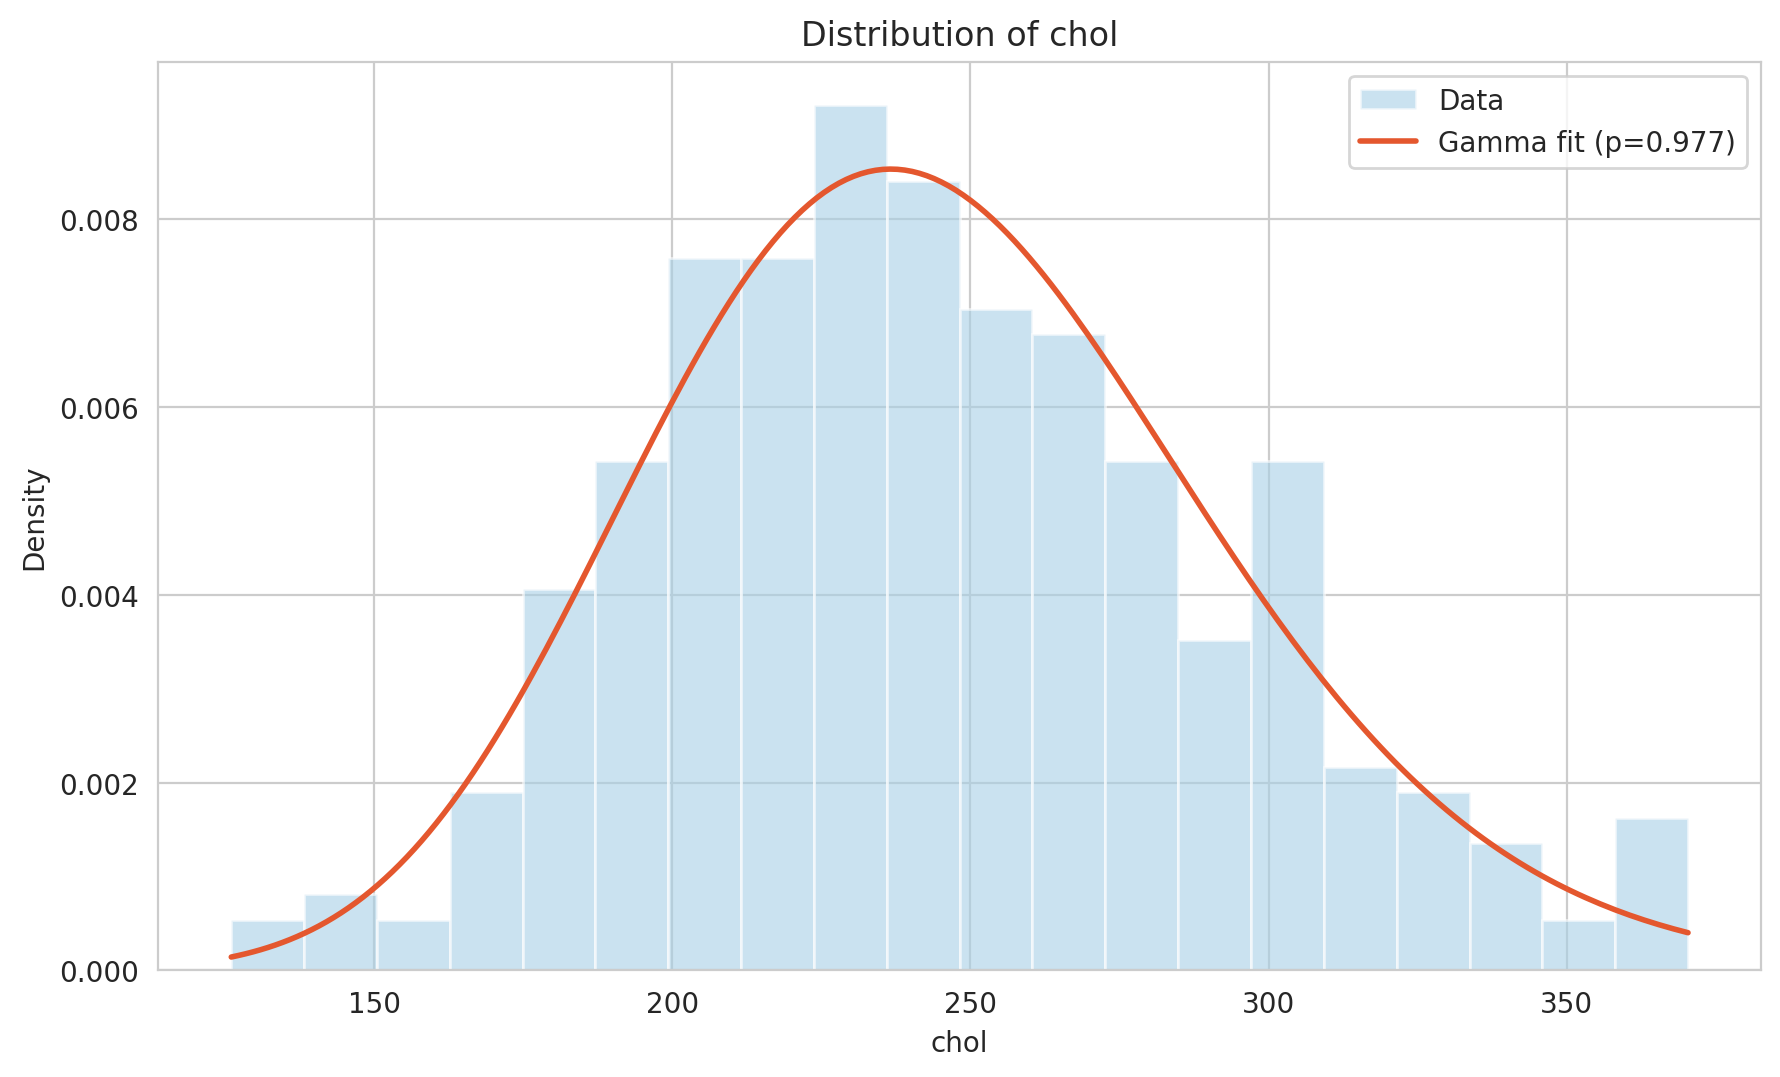

Saved: dashboard_hist_chol_gamma.png (cholesterol vs. fitted Gamma distribution)

In [2]:
# 1. Histogram with fitted distribution - cholesterol vs. Gamma
fig = plot_histogram_with_distribution(df['chol'], distribution='gamma', column_name='chol')
fig.savefig('../reports/figures/dashboard_hist_chol_gamma.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dashboard_hist_chol_gamma.png (cholesterol vs. fitted Gamma distribution)")

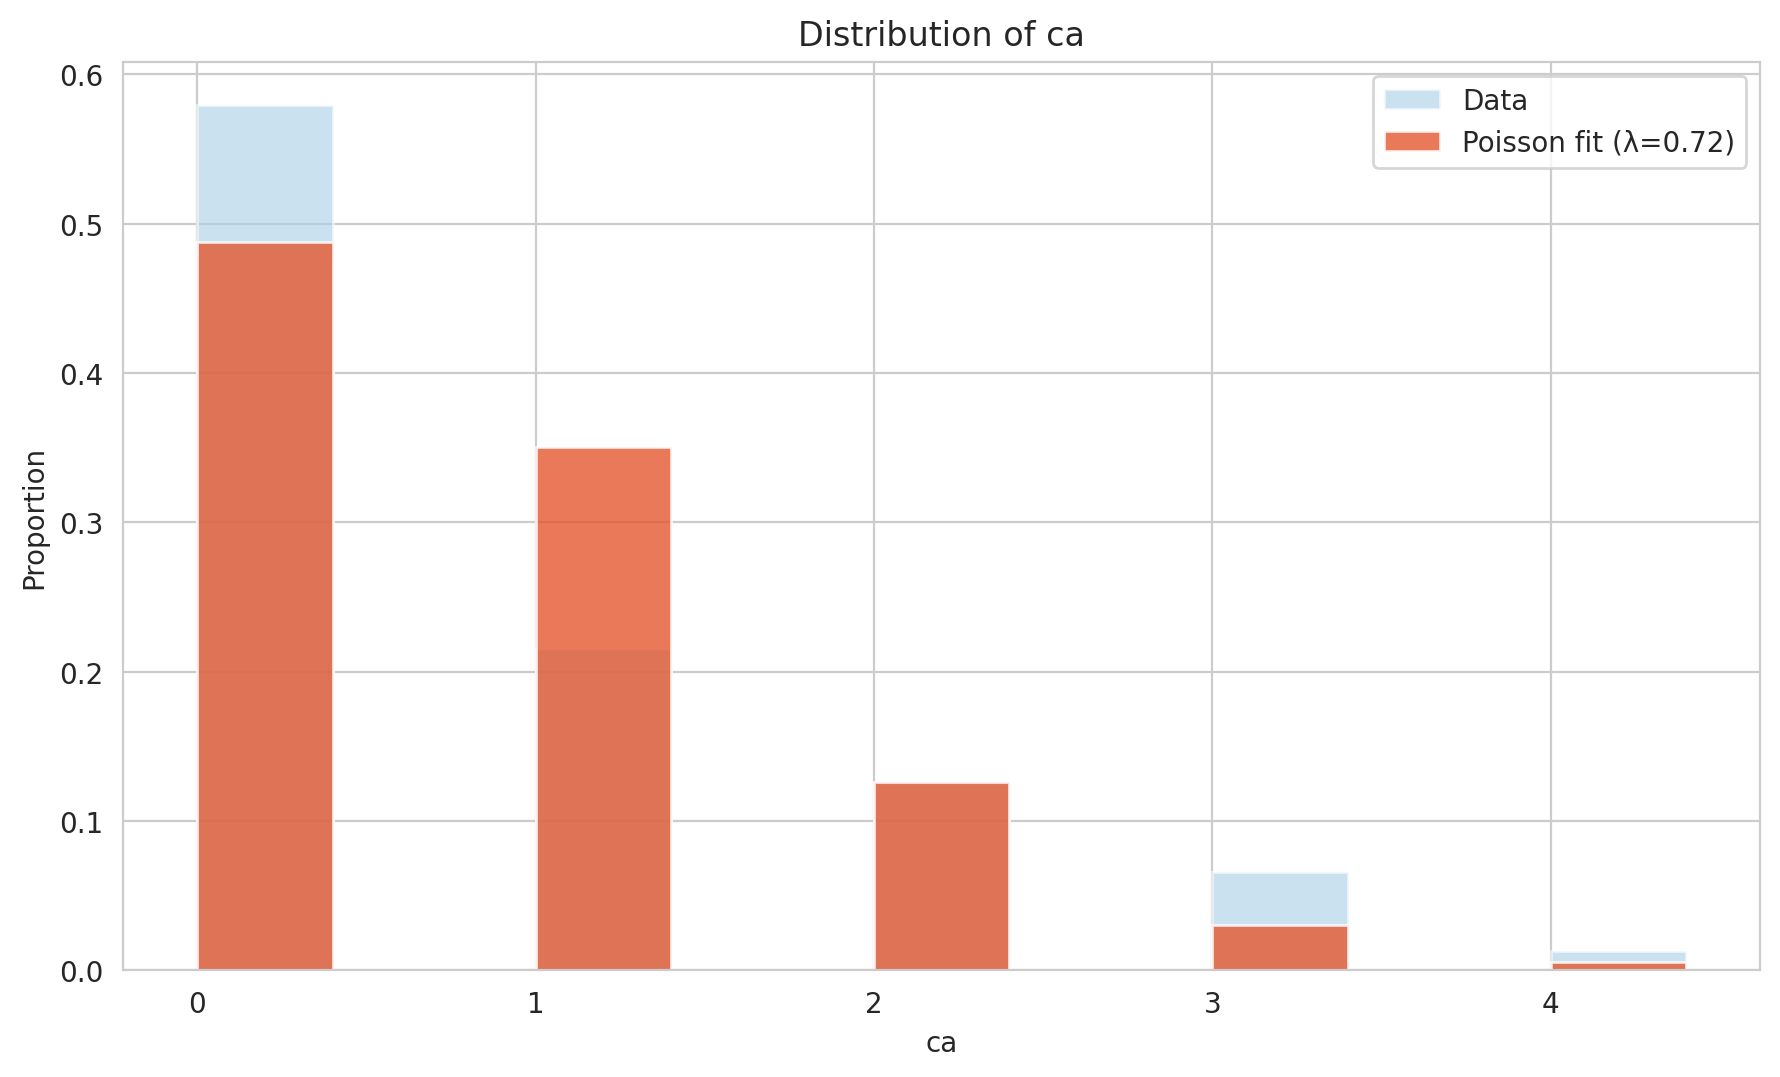

Saved: dashboard_hist_ca_poisson.png (number of vessels vs. fitted Poisson distribution)

In [3]:
# 2. Discrete distribution - number of vessels (ca) vs. Poisson
# 'ca' is a count (0-4), so it's a good candidate for a discrete fit -
# something Week 2's continuous-only fit_distribution() couldn't try.
fig = plot_histogram_with_distribution(df['ca'].astype(float), distribution='poisson', column_name='ca')
fig.savefig('../reports/figures/dashboard_hist_ca_poisson.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dashboard_hist_ca_poisson.png (number of vessels vs. fitted Poisson distribution)")

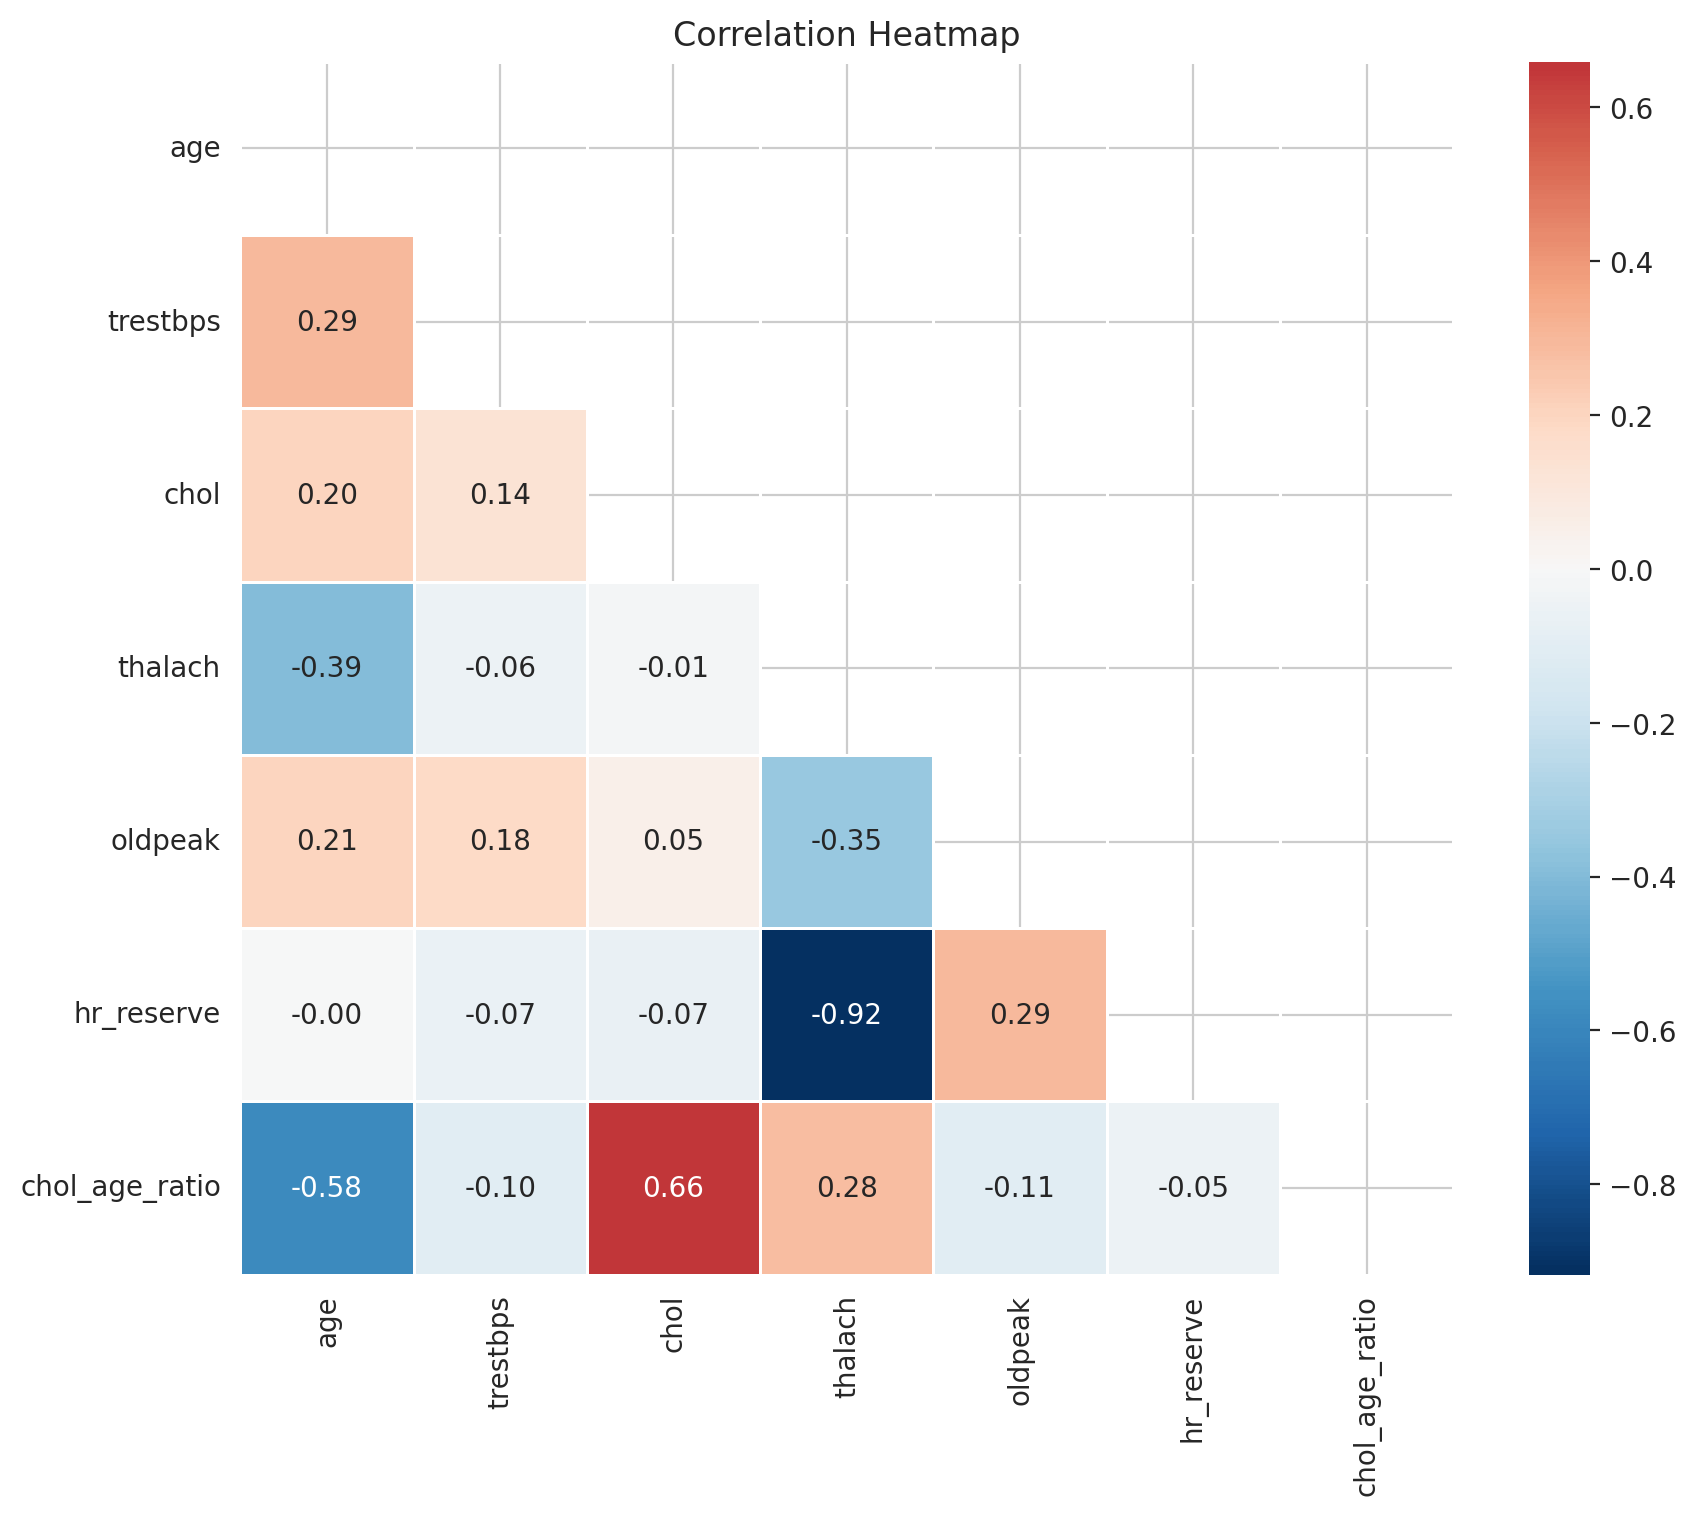

Saved: dashboard_correlation_heatmap.png

In [4]:
# 3. Correlation heatmap
fig = create_correlation_heatmap(df)
fig.savefig('../reports/figures/dashboard_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dashboard_correlation_heatmap.png")

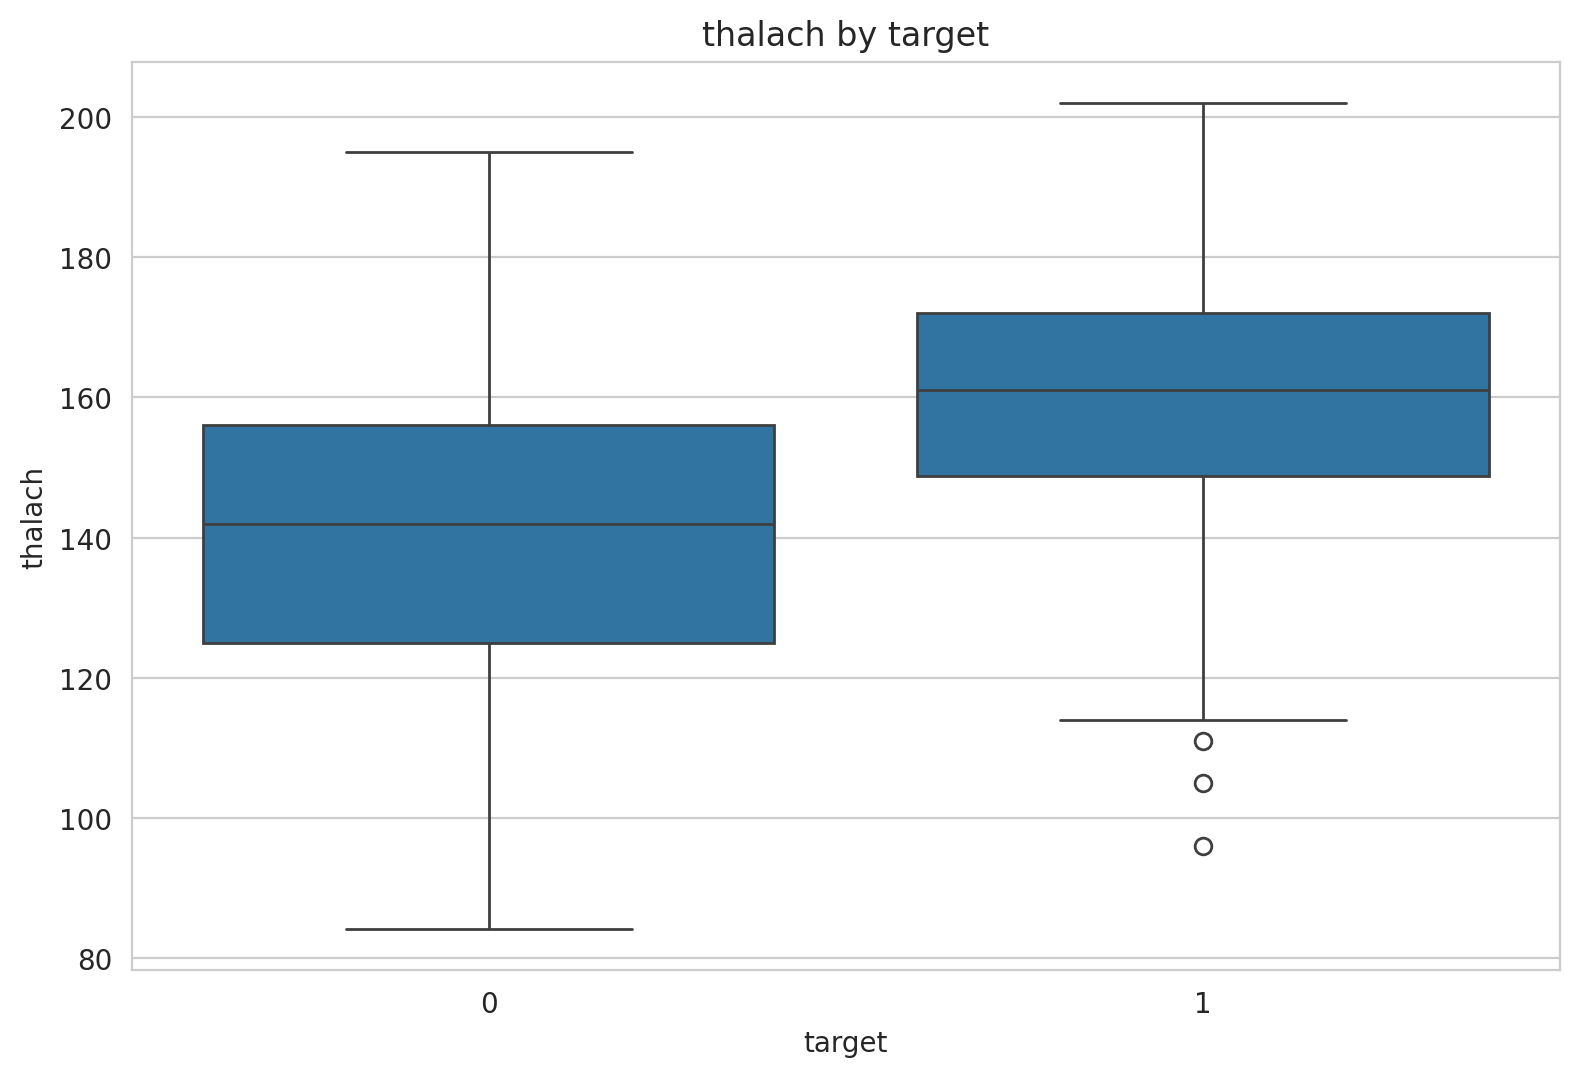

Saved: dashboard_boxplot_thalach_target.png

In [5]:
# 4. Boxplot by category - max heart rate by diagnosis
fig = plot_boxplots_by_category(df, numeric_col='thalach', category_col='target')
fig.savefig('../reports/figures/dashboard_boxplot_thalach_target.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dashboard_boxplot_thalach_target.png")

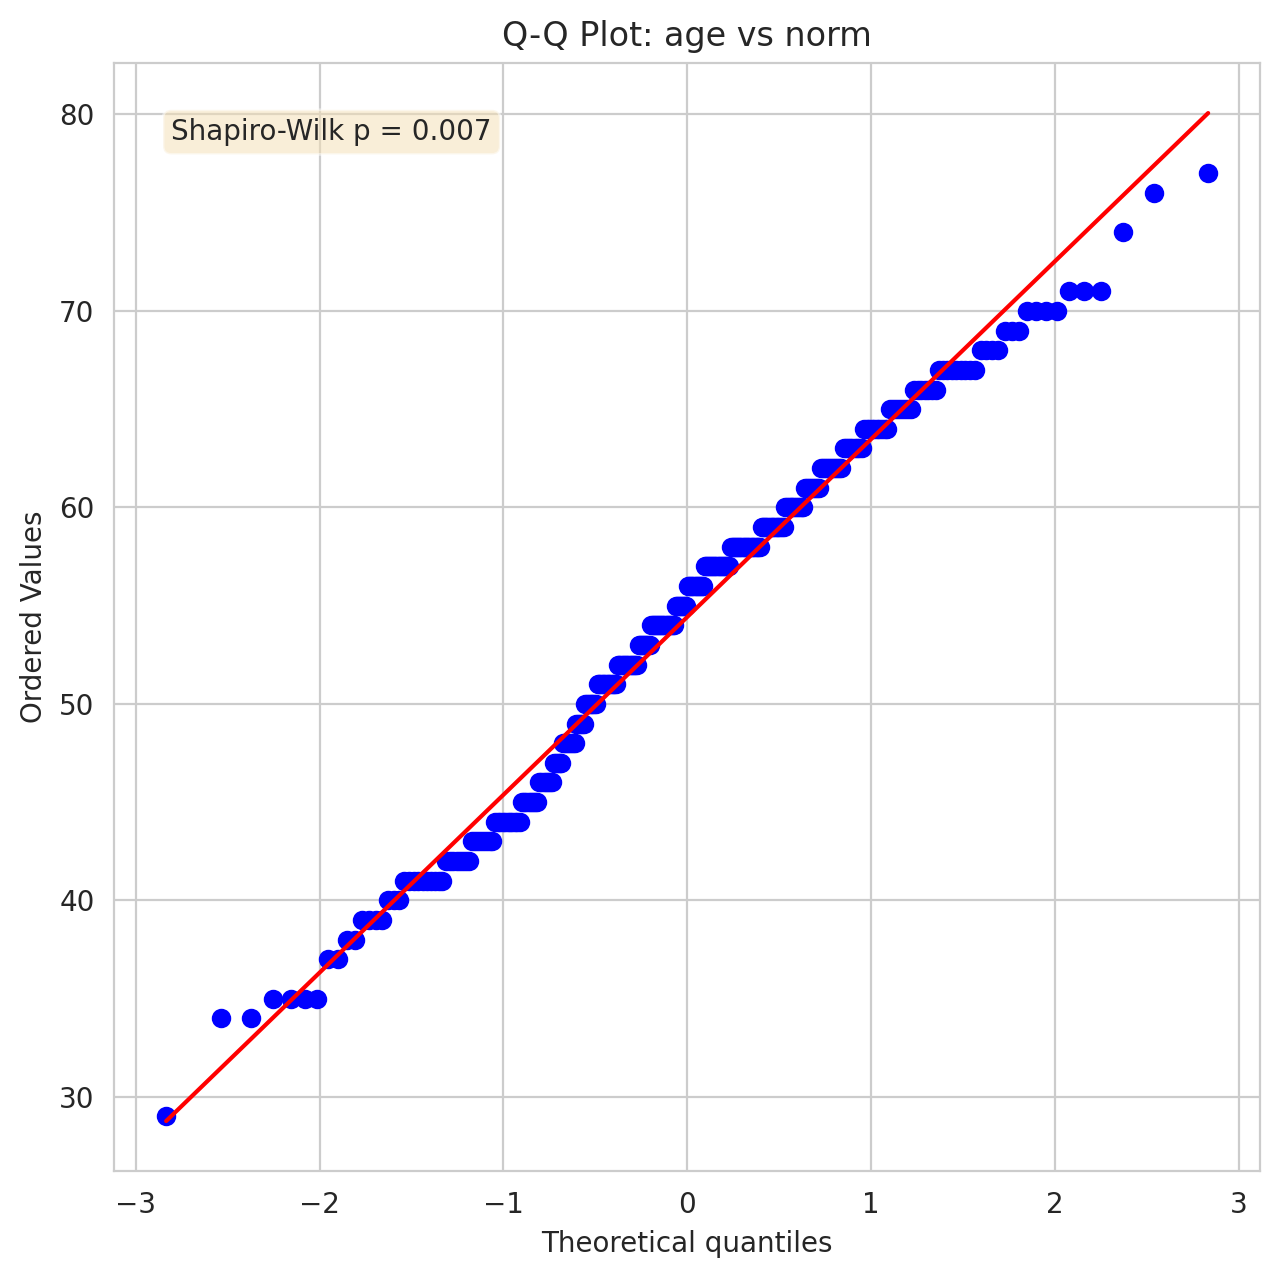

Saved: dashboard_qq_age.png

In [6]:
# 5. Q-Q plot for normality check - age
fig = plot_qq_comparison(df['age'], column_name='age')
fig.savefig('../reports/figures/dashboard_qq_age.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dashboard_qq_age.png")

In [7]:
# 6. Interactive scatter (Plotly) - age vs. cholesterol, colored by diagnosis
# This returns a plotly Figure; it renders inline here and is the same
# function the "Overview" tab of the Streamlit dashboard uses.
scatter_fig = create_interactive_scatter(df, x_col='age', y_col='chol', color_col='target')
scatter_fig.write_html('../reports/figures/dashboard_scatter_age_chol.html')
scatter_fig.show()

In [8]:
# 7. Dashboard layout configuration
# dashboard/app.py builds its sidebar and page config from this dict,
# so it can be unit tested without needing a Streamlit runtime.
config = dashboard_layout()
print("Dashboard layout configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Dashboard layout configuration:
  page_config: {'page_title': 'Statistics Superstars - Heart Disease Dashboard', 'page_icon': '🩺', 'layout': 'wide'}
  sidebar_title: 📊 Data Detective: Heart Disease
  datasets: ['Heart Disease']
  analysis_types: ['Overview', 'Distributions', 'Hypothesis Testing']
  numeric_columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'hr_reserve', 'chol_age_ratio']
  categorical_columns: ['target', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']